## MR4010 Navegacion autonoma

### Transformada de Hough y pipeline.

Referencia imagen original de ejercicio

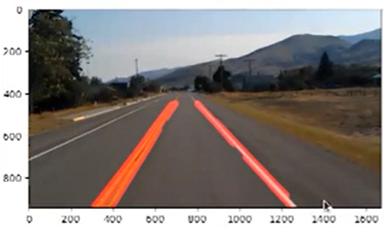

Pipeline clásico de visión para carriles:

Grayscale

Gaussian Blur

Canny Edge Detection

ROI (máscara)

Hough Transform (líneas)

Overlay final

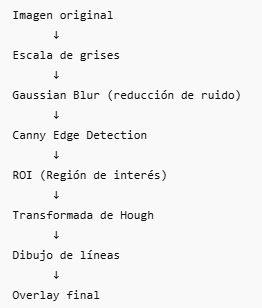

#### 1. LIBRERÍAS

In [29]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

#### 2. CARGA DE IMAGEN + CANNY

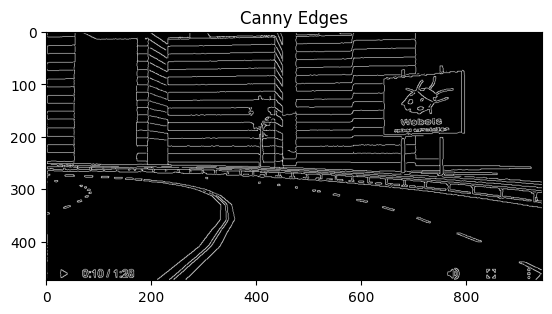

Shape: (474, 946)


In [30]:
# ==============================
# 2. CARGA DE IMAGEN + CANNY
# ==============================
IMAGE_PATH = "D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\Module1\Webot_image_V1.0.jpg"  # Cambia si es necesario

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

# Convertir a escala de grises
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Blur para reducir ruido
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Canny (detección de bordes)
img_canny = cv2.Canny(img_blur, 40, 120)

plt.imshow(img_canny, cmap='gray')
plt.title("Canny Edges")
plt.show()

print("Shape:", img_canny.shape)

#### 3. ROI (REGIÓN DE INTERÉS)

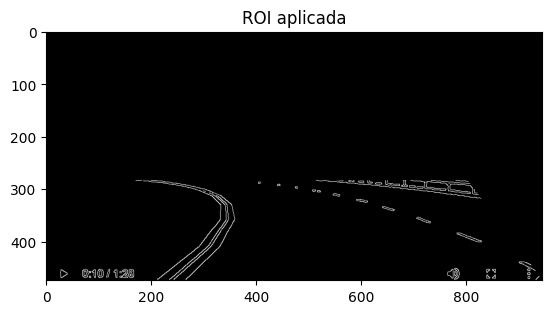

In [31]:
# ==============================
# 3. ROI (REGIÓN DE INTERÉS)
# ==============================
height, width = img_canny.shape

vertices = np.array([[
    (int(width * 0.0), int(height * 1)),   # abajo izquierda
    (int(width * 0.15), int(height * 0.6)),  # arriba izquierda
    (int(width * 0.85), int(height * 0.6)),  # arriba derecha
    (int(width * 1.0), int(height * 1))    # abajo derecha
]], dtype=np.int32)

# Crear máscara
img_roi = np.zeros_like(img_canny)
cv2.fillPoly(img_roi, vertices, 255)

# Aplicar máscara
img_mask = cv2.bitwise_and(img_canny, img_roi)

plt.imshow(img_mask, cmap='gray')
plt.title("ROI aplicada")
plt.show()

#### 4. TRANSFORMADA DE HOUGH

Líneas detectadas por Hough: 25
Líneas izquierdas filtradas: 5
Líneas derechas filtradas: 0


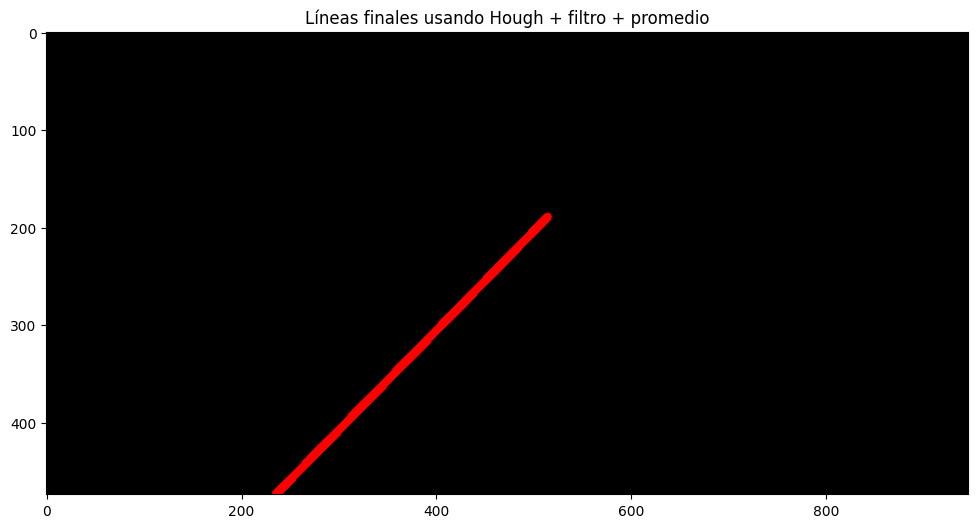

In [32]:
# ============================================
# 4. TRANSFORMADA DE HOUGH MEJORADA
# ============================================

# Parámetros de Hough
rho = 2                         # Resolución en píxeles
theta = np.pi / 180             # Resolución angular en radianes
threshold = 80                  # Número mínimo de votos para aceptar una línea
min_line_len = 100              # Longitud mínima de línea
max_line_gap = 50               # Separación máxima entre segmentos para unirlos

# Detectar segmentos de línea usando HoughLinesP
lines = cv2.HoughLinesP(
    img_mask,                   # Imagen con Canny + ROI aplicada
    rho,
    theta,
    threshold,
    np.array([]),
    minLineLength=min_line_len,
    maxLineGap=max_line_gap
)

# Imagen vacía donde se dibujarán las líneas finales
img_lines = np.zeros((height, width, 3), dtype=np.uint8)

# Listas para guardar líneas izquierda y derecha
left_lines = []
right_lines = []

# Filtros de pendiente
min_slope = 0.5                 # Elimina líneas casi horizontales
max_slope = 2.5                 # Elimina líneas demasiado verticales

# ============================================
# FILTRAR LÍNEAS POR PENDIENTE
# ============================================

if lines is not None:
    for line in lines:
        for x1, y1, x2, y2 in line:

            # Evitar división entre cero
            if x2 - x1 == 0:
                continue

            # Calcular pendiente e intercepto
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1

            # Eliminar líneas horizontales o demasiado verticales
            if abs(slope) < min_slope:
                continue

            if abs(slope) > max_slope:
                continue

            # Separar líneas por lado
            # En imágenes, y crece hacia abajo
            if slope < 0:
                left_lines.append((slope, intercept))
            else:
                right_lines.append((slope, intercept))

print("Líneas detectadas por Hough:", len(lines) if lines is not None else 0)
print("Líneas izquierdas filtradas:", len(left_lines))
print("Líneas derechas filtradas:", len(right_lines))


# ============================================
# FUNCIÓN PARA CREAR UNA LÍNEA COMPLETA
# ============================================

def make_line(height, slope, intercept):
    """
    Convierte pendiente e intercepto en dos puntos x1,y1,x2,y2.
    Esto permite dibujar una línea larga en lugar de muchos segmentos pequeños.
    """

    y1 = height                  # Parte inferior de la imagen
    y2 = int(height * 0.40)      # Parte superior de la línea dentro del ROI

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return x1, y1, x2, y2


# ============================================
# PROMEDIAR Y DIBUJAR LÍNEA IZQUIERDA
# ============================================

if len(left_lines) > 0:
    left_avg = np.mean(left_lines, axis=0)
    left_slope = left_avg[0]
    left_intercept = left_avg[1]

    x1, y1, x2, y2 = make_line(height, left_slope, left_intercept)

    # Dibujar línea izquierda en rojo
    cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 8)


# ============================================
# PROMEDIAR Y DIBUJAR LÍNEA DERECHA
# ============================================

if len(right_lines) > 0:
    right_avg = np.mean(right_lines, axis=0)
    right_slope = right_avg[0]
    right_intercept = right_avg[1]

    x1, y1, x2, y2 = make_line(height, right_slope, right_intercept)

    # Dibujar línea derecha en verde
    cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 8)


# ============================================
# MOSTRAR LÍNEAS DETECTADAS
# ============================================

plt.figure(figsize=(12, 6))
plt.imshow(img_lines)
plt.title("Líneas finales usando Hough + filtro + promedio")
plt.show()

#### 5. OVERLAY FINAL

In [28]:
# ============================================
# 5. OVERLAY FINAL
# ============================================

alpha = 0.8
beta = 1.0
gamma = 0.0

# Convertir imagen original BGR a RGB para matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Combinar imagen original con las líneas detectadas
img_lane_lines = cv2.addWeighted(img_rgb, alpha, img_lines, beta, gamma)

plt.figure(figsize=(12, 6))
plt.imshow(img_lane_lines)
plt.title("Resultado final - Líneas de carril")
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:665: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'cv::arithm_op'


🔴 ¿Qué es la Transformada de Hough?

Es un método para detectar líneas rectas en una imagen.

👉 No trabaja directamente en la imagen

👉 Trabaja en un espacio matemático (ρ, θ)

#### 🧠 Idea clave (la más importante)

Cada punto blanco (edge) en tu imagen puede pertenecer a MUCHAS líneas posibles.

Entonces Hough hace esto:

Toma un punto (x, y)

Calcula todas las líneas posibles que pasan por ese punto

Vota en un “mapa acumulador”

Donde hay muchas intersecciones → hay una línea real

📐 Ecuación que usa

ρ=xcos(θ)+ysin(θ)

ρ = distancia desde el origen

θ = ángulo de la línea

🔄 ¿Cómo se ve el proceso?

1. Imagen con bordes (tu Canny)

Solo píxeles blancos (edges)

2. Cada punto vota en (ρ, θ)

Se crea un “mapa de votos”

3. Picos en el mapa = líneas detectadas

🚗 Aplicado a tu código

#### Tu pipeline es correcto:

1. Canny

✔ Detecta bordes

✔ Pero detecta MUCHÍSIMO ruido

2. ROI

✔ Bien aplicado

✔ Quitaste cielo → 👍

3. HoughLinesP

Aquí está el problema principal 👇

threshold = 40

min_line_len = 50

max_line_gap = 100

#### 👉 Esto está demasiado permisivo

Resultado:

Detecta TODO

Incluye ruido

Genera ese “spaghetti rojo” que ves

⚠️ ¿Por qué tu resultado está mal?

#### En tu imagen final:

Detecta líneas del cofre 🚗

Detecta ruido del asfalto

Detecta sombras

Detecta bordes pequeños


#### 👉 No está filtrando “líneas de carril”, solo “cualquier línea”

#### IMPLEMENTADO PARA VIDEO MP4

## CHULADA

In [14]:
def smooth_line(current_line, previous_line, alpha=0.2):
    """
    Suaviza la línea actual usando la línea del frame anterior.
    Evita que las líneas parpadeen frame a frame.
    """

    if current_line is None:
        return previous_line

    if previous_line is None:
        return current_line

    return [
        int(alpha * current_line[0] + (1 - alpha) * previous_line[0]),
        int(alpha * current_line[1] + (1 - alpha) * previous_line[1]),
        int(alpha * current_line[2] + (1 - alpha) * previous_line[2]),
        int(alpha * current_line[3] + (1 - alpha) * previous_line[3])
    ]

### FILTRO DE COLOR AMARILLO

In [35]:
import cv2
import numpy as np

# ==============================
# SUAVIZADO TEMPORAL
# ==============================
yellow_line_prev = None
alpha_smooth = 0.25

def smooth_line(current_line, previous_line, alpha=0.25):
    if current_line is None:
        return previous_line
    if previous_line is None:
        return current_line

    return [
        int(alpha * current_line[0] + (1 - alpha) * previous_line[0]),
        int(alpha * current_line[1] + (1 - alpha) * previous_line[1]),
        int(alpha * current_line[2] + (1 - alpha) * previous_line[2]),
        int(alpha * current_line[3] + (1 - alpha) * previous_line[3])
    ]

def make_line(height, slope, intercept):
    """
    Creates one extended reference line from slope/intercept.
    """
    y1 = int(height * 0.95)   # bottom
    y2 = int(height * 0.75)   # upper ROI

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return [x1, y1, x2, y2]


# ==============================
# VIDEO
# ==============================
video_path = "../../data/Video/city_2025a_05062026.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("No se pudo abrir el video. Revisa la ruta.")

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    height, width, _ = frame.shape

    # ==============================
    # 1. FILTRO DE COLOR AMARILLO
    # ==============================
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Rango amarillo en HSV
    lower_yellow = np.array([15, 80, 80])
    upper_yellow = np.array([40, 255, 255])

    yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # Limpieza de ruido
    kernel = np.ones((5, 5), np.uint8)
    yellow_mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_OPEN, kernel)
    yellow_mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel)

    # ==============================
    # 2. ROI SOLO ZONA BAJA / CENTRAL
    # ==============================
    roi_mask = np.zeros_like(yellow_mask)

    vertices = np.array([[
        (int(width * 0.00), int(height * 1.00)),
        (int(width * 0.10), int(height * 0.55)),
        (int(width * 0.60), int(height * 0.55)),
        (int(width * 0.55), int(height * 1.00))
    ]], dtype=np.int32)

    cv2.fillPoly(roi_mask, vertices, 255)

    yellow_roi = cv2.bitwise_and(yellow_mask, roi_mask)

    # ==============================
    # 3. CANNY SOBRE MÁSCARA AMARILLA
    # ==============================
    blur = cv2.GaussianBlur(yellow_roi, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # ==============================
    # 4. HOUGH PARA LÍNEA AMARILLA
    # ==============================
    lines = cv2.HoughLinesP(
        edges,
        rho=2,
        theta=np.pi / 180,
        threshold=40,
        minLineLength=60,
        maxLineGap=80
    )

    yellow_candidates = []

    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:

                if x2 - x1 == 0:
                    continue

                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1

                # Yellow middle line in your image has negative slope
                if slope > -3.0 and slope < -0.3:
                    yellow_candidates.append((slope, intercept))

    yellow_current = None

    if len(yellow_candidates) > 0:
        avg_line = np.mean(yellow_candidates, axis=0)
        yellow_current = make_line(height, avg_line[0], avg_line[1])

    # ==============================
    # 5. SUAVIZAR Y DIBUJAR
    # ==============================
    yellow_line_prev = smooth_line(
        yellow_current,
        yellow_line_prev,
        alpha_smooth
    )

    img_lines = np.zeros_like(frame)

    if yellow_line_prev is not None:
        x1, y1, x2, y2 = yellow_line_prev
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 255), 10)

        # Punto de referencia en la parte baja
        cv2.circle(img_lines, (x1, y1), 8, (0, 0, 255), -1)

    result = cv2.addWeighted(frame, 0.85, img_lines, 1.0, 0)

    # Debug opcional
    cv2.imshow("Yellow Mask", cv2.resize(yellow_roi, (800, 450)))
    cv2.imshow("Yellow Center Line Detection", cv2.resize(result, (800, 450)))

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

### Con escala de grises

In [3]:
import cv2
import numpy as np

# ==============================
# SUAVIZADO TEMPORAL
# ==============================
gray_line_prev = None
alpha_smooth = 0.25

def smooth_line(current_line, previous_line, alpha=0.25):
    if current_line is None:
        return previous_line
    if previous_line is None:
        return current_line

    return [
        int(alpha * current_line[0] + (1 - alpha) * previous_line[0]),
        int(alpha * current_line[1] + (1 - alpha) * previous_line[1]),
        int(alpha * current_line[2] + (1 - alpha) * previous_line[2]),
        int(alpha * current_line[3] + (1 - alpha) * previous_line[3])
    ]

def make_line(height, slope, intercept):
    """
    Creates one extended reference line from slope/intercept.
    """
    y1 = int(height * 0.95)   # bottom
    y2 = int(height * 0.75)   # upper ROI

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return [x1, y1, x2, y2]


# ==============================
# VIDEO
# ==============================
video_path = "../../data/Video/city_2025a_05062026.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("No se pudo abrir el video. Revisa la ruta.")

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    height, width, _ = frame.shape

    # ==============================
    # 1. CONVERTIR A ESCALA DE GRISES
    # ==============================
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Rango de intensidad para detectar línea clara / amarilla convertida a gris
    lower_gray = 120
    upper_gray = 255

    gray_mask = cv2.inRange(gray, lower_gray, upper_gray)

    # Limpieza de ruido
    kernel = np.ones((5, 5), np.uint8)
    gray_mask = cv2.morphologyEx(gray_mask, cv2.MORPH_OPEN, kernel)
    gray_mask = cv2.morphologyEx(gray_mask, cv2.MORPH_CLOSE, kernel)

    # ==============================
    # 2. ROI SOLO ZONA BAJA / CENTRAL
    # ==============================
    roi_mask = np.zeros_like(gray_mask)

    vertices = np.array([[
        (int(width * 0.00), int(height * 1.00)),
        (int(width * 0.10), int(height * 0.55)),
        (int(width * 0.60), int(height * 0.55)),
        (int(width * 0.55), int(height * 1.00))
    ]], dtype=np.int32)

    cv2.fillPoly(roi_mask, vertices, 255)

    gray_roi = cv2.bitwise_and(gray_mask, roi_mask)

    # ==============================
    # 3. CANNY SOBRE MÁSCARA GRIS
    # ==============================
    blur = cv2.GaussianBlur(gray_roi, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # ==============================
    # 4. HOUGH PARA LÍNEA GRAY
    # ==============================
    lines = cv2.HoughLinesP(
        edges,
        rho=2,
        theta=np.pi / 180,
        threshold=40,
        minLineLength=60,
        maxLineGap=80
    )

    gray_candidates = []

    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:

                if x2 - x1 == 0:
                    continue

                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1

                # Línea central con pendiente negativa
                if -3.0 < slope < -0.3:
                    gray_candidates.append((slope, intercept))

    gray_current = None

    if len(gray_candidates) > 0:
        avg_line = np.mean(gray_candidates, axis=0)
        gray_current = make_line(height, avg_line[0], avg_line[1])

    # ==============================
    # 5. SUAVIZAR Y DIBUJAR
    # ==============================
    gray_line_prev = smooth_line(
        gray_current,
        gray_line_prev,
        alpha_smooth
    )

    img_lines = np.zeros_like(frame)

    if gray_line_prev is not None:
        x1, y1, x2, y2 = gray_line_prev
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 255), 10)

        # Punto de referencia en la parte baja
        cv2.circle(img_lines, (x1, y1), 8, (0, 0, 255), -1)

    result = cv2.addWeighted(frame, 0.85, img_lines, 1.0, 0)
    

    # Debug
    cv2.imshow("Gray Original", cv2.resize(gray, (800, 450)))
    cv2.imshow("Gray Mask ROI", cv2.resize(gray_roi, (800, 450)))
    cv2.imshow("Gray Line Detection", cv2.resize(result, (800, 450)))
    

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()